In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  2 15:56:49 2022

@author: Francisco Sequeira
"""

import numpy as np
import pickle
from astropy import units as u
from astropy.io import fits 
from astropy.coordinates import Angle, SkyCoord
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.visualization.wcsaxes import SphericalCircle, Quadrangle, add_beam
from astropy.visualization import LogStretch, ImageNormalize
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

### Set the dictionary with the information for the regions (inset and zoom in the image) and molecular outflows

Contour data for the SOMA region images
Firsts values (Cont_Levels_SOMA) corresponds to the contour levels for the whole image (Only at C band),
the other values (Cont_Levels_Zoom) corresponds to the contour levels of the zoom image.
All the contour levels were determined using the CASA viewer
The values of the Zoom_parameters belong to the coordinates of a box made in casa (xy) and width and height
The last values corresponds to parameters for the outflow region made manually with the contour image, 
this was made with the contour_single_source.py

In [ ]:
table_coord = 'Data/Tables/SOMA_coordinates.txt'
t_coord = np.genfromtxt(table_coord, names=True, dtype=None, encoding=None)
contour_levels_dic={}
contour_levels_zoom_dic={}

for i, source in enumerate(t_coord['source']): 
    contour_levels_dic[source]={}
    contour_levels_dic[source]={'C_rms':t_coord['C_rms'][i], 'K_rms':t_coord['K_rms'][i]}
    
    ### SOMA II ###
    if source == 'G45.12+0.13':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-10, 10, 50, 200, 500]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-10, 10, 50, 200, 500], 'K':[-7, 7, 50, 200, 500]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'19:13:28.450', 'Dec':'+10:53:44.453', 'l': 13.75, 'source_factor': 1, 'vmax': 6}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-8.0, 'yb':-4.8, 'x':12.5, 'y':-25.5, 'xr':-9.4, 'yr':-1.8}
        
        contour_levels_dic[source]['Outflow_parameters_2']={'xb':-6.5, 'yb':-5.0, 'x':-6.5, 'y':32.5, 'xr':-6.8, 'yr':-5.3}
        
    elif source == 'G309.92+0.48':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-5, 5, 7, 50, 200, 400]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-5, 5, 7, 50, 200, 400], 'K':[-5, 5, 20, 150, 300, 400]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'13:50:42.22', 'Dec':'-61:35:08.065', 'l': 5.14, 'source_factor': 2, 'vmax': 16}
        
    elif source == 'G35.58-0.03':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-5, 5, 25, 250, 800]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-5, 5, 25, 200, 500, 900], 'K':[-5, 5, 25, 70, 300]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'18:56:22.843', 'Dec':'+02:20:31.730',  'l': 8.1, 'source_factor': 1, 'vmax': 12}

        contour_levels_dic[source]['Outflow_parameters']={'xb':5.0, 'yb':-3.2, 'x':6.5, 'y':-6.5, 'xr':-3.4, 'yr':3.2}

    elif source == 'IRAS_16562':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-7, 7, 15, 50, 100, 150, 250]}

        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-7, 7, 15, 50, 100, 150, 250], 'K':[-7, 7, 20, 75, 150, 400]}

        contour_levels_dic[source]['Zoom_parameters']={'RA':'16:59:41.92', 'Dec':'-40:03:41.45',  'l': 7.5, 'source_factor': 1, 'vmax': 12}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-3.0, 'yb':-0.5, 'x':-15, 'y':-2.5, 'xr':3.0, 'yr':0.5}
        
        contour_levels_dic[source]['Outflow_parameters_2']={'xb':0.2, 'yb':-6.3, 'x':0.7, 'y':-13.5, 'xr':0.2, 'yr':4.5}

    elif source == 'IRAS_16562_N':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-1000,-200,3]}

    elif source == 'G305.20+0.21':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-5, 5, 7, 10, 12, 14]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-5, 5, 7, 10, 12, 14], 'K':[-3, 3, 6, 10]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'13:11:10.83', 'Dec':'-62:34:36.73',  'l': 3.2, 'source_factor': 2, 'vmax': 16}
        
    elif source == 'G305.20+0.21A':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 5]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 5], 'K':[-3, 3, 5, 10]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'13:11:13.98', 'Dec':'-62:34:39.76',  'l': 3.0, 'source_factor': 2, 'vmax': 12}
        
    elif source == 'G49.27-0.34':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-5, 5, 12, 20, 30]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-6, 4, 7, 15], 'K':[-5, 5, 7, 10, 20, 30]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'19:23:06.705', 'Dec':'+14:20:13.43',  'l': 2.87, 'source_factor': 1, 'vmax': 3}
        
    elif source == 'G339.88-1.26':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-4, 4, 10, 30, 60]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-4, 4, 10, 20, 40, 60], 'K':[-3, 3, 10, 30]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'16:52:05.273', 'Dec':'-46:08:28.30', 'l': 8.1, 'source_factor': 1.5, 'vmax': 6}
        
        contour_levels_dic[source]['Outflow_parameters']={'xr':-3.0, 'yr':-2.6, 'x':6.5, 'y':6.0,'xb':2.9, 'yb':2.5}
        
        contour_levels_dic[source]['Outflow_parameters_3']={'xb':2.0, 'yb':-2.5, 'x':9.5, 'y':-13.5}

        contour_levels_dic[source]['Outflow_parameters_4']={'xr':0.0, 'yr':3.5, 'x':-1.5, 'y':13.5}
    
    ### SOMA III ###
    elif source == 'S235':
         contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 7, 15, 20]}
       
         contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 7, 15, 20], 'K':[-3, 3, 7, 15, 25, 35]}
         
         contour_levels_dic[source]['Zoom_parameters']={'RA':'05:40:52.432', 'Dec':'+35:41:30.26', 'l': 2, 'source_factor': 1, 'vmax': 16}
         
    elif source == 'IRAS_22198':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 15, 25, 50, 65]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 15, 25, 50, 65], 'K':[-3, 3, 7, 15, 25, 40]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'22:21:26.88', 'Dec':'+63:51:38.8', 'l': 1.9, 'source_factor': 2, 'vmax': 3}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-1.0, 'yb':1.8, 'x':-1.5, 'y':2, 'xr':2.0, 'yr':-2.5}
        
        contour_levels_dic[source]['Outflow_parameters_2']={'xb':-0.8, 'yb':-2.5, 'x':-1.2, 'y':-1.8, 'xr':2.8, 'yr':1.5}
        
    elif source == 'NGC_2071':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 7, 30, 120]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 10, 30, 120], 'K':[-3, 3, 10, 25, 60, 120]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'05:47:04.916', 'Dec':'+00:21:44.65', 'l': 3.1, 'source_factor': 1, 'vmax': 12}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-3.7, 'yb':3.2, 'x':-5.7, 'y':5.15, 'xr':2.5, 'yr':-3.2}
        
    elif source == 'Cepheus_E':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 5], 'K':[-3, 3, 7, 15, 20]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 5], 'K':[-3, 3, 7, 15, 20]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'23:03:12.905', 'Dec':'+61:42:26.771', 'l': 1.75, 'source_factor': 2, 'vmax': 3}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-1.2, 'yb':2., 'x':-3.5, 'y':4, 'xr':1.2, 'yr':-2}
        
    elif source == 'L1206_A':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 4, 6]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 4, 6], 'K':[-3, 3, 7, 15, 25, 40]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'22:28:51.696', 'Dec':'+64:13:42.329', 'l': 2.35, 'source_factor': 2.5, 'vmax': 3}
                                                   
        contour_levels_dic[source]['Outflow_parameters']={'xb':0.9, 'yb':2.2, 'x':2.0, 'y':2.0, 'xr':-3.0, 'yr':-2.0}
        
    elif source == 'L1206_B':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 5]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 5], 'K':[-3, 3, 5, 8, 11]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'22:28:57.751', 'Dec':'+64:13:38.273', 'l': 1.75, 'source_factor': 2.5, 'vmax': 3}
        
    elif source == 'IRAS_22172_MIR1':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 5], 'K':[-3, 5]}
        
    elif source == 'IRAS_22172_MIR2':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 5], 'K':[-3, 5]}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-0.5, 'yb':0.8, 'x':-0.5, 'y':1.5, 'xr':0.0, 'yr':-0.8}
        
    elif source == 'IRAS_22172_MIR3':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 5], 'K':[-3, 5]}
        
    elif source == 'IRAS_21391_BIMA2':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 5, 15, 30, 45]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 5, 15, 30, 45], 'K':[-3, 3, 10, 25, 45]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'21:40:42.069', 'Dec':'+58:16:15.06', 'l': 3.8, 'source_factor': 2, 'vmax': 3}
        
        contour_levels_dic[source]['Outflow_parameters']={'xb':-2.5, 'yb':2.0, 'x':-3.41459, 'y':2.591, 'xr':2.7, 'yr':-2.0}
        
    elif source == 'IRAS_21391_BIMA3':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 3, 5, 10, 25]}
        
        contour_levels_dic[source]['Cont_Levels_Zoom']={'C':[-3, 3, 5, 10, 25], 'K':[-3, 3, 10, 16, 25]}
        
        contour_levels_dic[source]['Zoom_parameters']={'RA':'21:40:42.98', 'Dec':'+58:16:02.33', 'l': 2.15, 'source_factor': 2, 'vmax': 3}
        
    elif source == 'IRAS_21391_MIR48':
        contour_levels_dic[source]['Cont_Levels_SOMA']={'C':[-3, 5], 'K':[-3, 5]}

    else:
        continue
    
pickle.dump(contour_levels_dic, open('Data/Dictionaries/contour_levels_dic.p', 'wb'))

### Marks and labels for the full contour plot

In [3]:
def plot_label_mark(source_name, wcs_IR, ax):
    ### SOMA II ###
    if source_name == 'G45.12+0.13': 
        c = SkyCoord(ra='19:13:28.18', dec='+10:53:45.85', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('S14', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='19:13:30.031', dec='+10:53:59.50', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('S20', xy=(x, y), fontsize=8, color='blue')#color='deepskyblue')

        # mm core Hunter 1997
        c = SkyCoord(ra='19:11:06.237', dec='+10:48:25.82', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'G309.92+0.48': 
        c = SkyCoord(ra='13:50:42.067', dec='-61:35:07.664', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('ATCA1', xy=(x, y), fontsize=8, color='blue')
        
        c = SkyCoord(ra='13:50:42.555', dec='-61:35:06.615', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('ATCA2', xy=(x, y), fontsize=8, color='blue')

        # mm core Hill 2005
        c = SkyCoord(ra='13:50:41.6', dec='-61:35:15.0', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'G35.58-0.03': 
        c = SkyCoord(ra='18:56:22.751', dec='+02:20:35.601', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('30B', xy=(x, y), fontsize=8, color='blue')

        # mm core Zhang 2018
        c = SkyCoord(ra='18:56:22.55', dec='+02:20:27.71', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'IRAS_16562': 
        c = SkyCoord(ra='16:59:41.585', dec='-40:03:40.269', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('C', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:41.992', dec='-40:03:41.484', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('I-E', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:41.358', dec='-40:03:39.622', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('I-W', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:42.33', dec='-40:03:30.8', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('1', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:42.42', dec='-40:03:31.0', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('+', xy=(x, y), fontsize=7, color='cyan')  

        c = SkyCoord(ra='16:59:42.77', dec='-40:03:35.8', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('2', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:42.86', dec='-40:03:36.3', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('+', xy=(x, y), fontsize=7, color='cyan')  

        c = SkyCoord(ra='16:59:41.576', dec='-40:03:47.895', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('3', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='16:59:41.67', dec='-40:03:47.9', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('+', xy=(x, y), fontsize=7, color='cyan')  

        c = SkyCoord(ra='16:59:40.875', dec='-40:03:43.859', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('4', xy=(x, y), fontsize=8, color='blue')

        # mm core Guzman 2014
        c = SkyCoord(ra='16:59:42.85', dec='-40:03:36.2', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

        c = SkyCoord(ra='16:59:41.63', dec='-40:03:43.59', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'G305.20+0.21A': 
        # Walsh 2016
        c = SkyCoord(ra='13:11:13.70', dec='-62:34:41.4', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'G305.20+0.21': 
        c = SkyCoord(ra='13:11:10.611', dec='-62:34:36.33', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('1', xy=(x, y), fontsize=8, color='blue')
    
        c = SkyCoord(ra='13:11:10.088', dec='-62:34:39.10', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('2', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='13:11:09.426', dec='-62:34:36.82', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('3', xy=(x, y), fontsize=8, color='blue')
        
        c = SkyCoord(ra='13:11:11.051', dec='-62:34:37.13', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('4', xy=(x, y), fontsize=8, color='blue')

    elif source_name == 'G49.27-0.34': 
        c = SkyCoord(ra='19:23:06.956', dec='14:20:22.96', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('CM1', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='19:23:06.739', dec='14:19:59.67', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('CM3', xy=(x, y), fontsize=8, color='blue')

    elif source_name == 'G339.88-1.26': 
        c = SkyCoord(ra='16:52:04.156', dec='-46:08:37.11', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('SW', xy=(x, y), fontsize=8, color='blue')

        # Zhang 2019
        c = SkyCoord(ra='16:52:04.67', dec='-46:08:34.16', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    ### SOMA III ###
    elif source_name == 'IRAS_22198': 
        # mm core Sanchez-Monge 2010
        c = SkyCoord(ra='22:21:26.68', dec='+63:51:38.2', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'NGC_2071':
        c = SkyCoord(ra='05:47:04.775', dec='+00:21:46.458', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('VLA1', xy=(x, y), fontsize=8, color='blue')
        
        c = SkyCoord(ra='05:47:04.681', dec='+00:21:48.672', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('IRS 3', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='05:47:04.645', dec='+00:21:41.808', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('H361E', xy=(x, y), fontsize=8, color='blue')
        
        c = SkyCoord(ra='05:47:04.335', dec='+00:21:38.892', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('IRS 8', xy=(x, y), fontsize=8, color='blue')        
        
        c = SkyCoord(ra='05:47:04.315', dec='+00:21:38.048', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('+', xy=(x, y), fontsize=7, color='cyan')  

        c = SkyCoord(ra='05:47:05.157', dec='+00:21:43.585', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('IRS 1Eb', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='05:47:04.845', dec='+00:21:40.759', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('IRS 1', xy=(x, y), fontsize=8, color='blue')

        # mm core Cheng 2022
        mm_data = [{'ra': '05:47:04.784', 'dec': '+00:21:42.85'},  # IRS1
                   {'ra': '05:47:04.755', 'dec': '+00:21:45.45'},  # VLA1
                   {'ra': '05:47:04.631', 'dec': '+00:21:47.82'},  # IRS3
                   {'ra': '05:47:04.317', 'dec': '+00:21:38.03'},  # IRS8
                   {'ra': '05:47:04.623', 'dec': '+00:21:41.30'},]  # H361E
        
        for s in mm_data:
            c = SkyCoord(ra=s['ra'], dec=s['dec'], unit=(u.hourangle, u.deg))
            c_fk5 = c.transform_to('fk5')
            ra=c_fk5.ra.degree
            dec=c_fk5.dec.degree
            x, y = wcs_IR.all_world2pix(ra, dec, 0)
            ax.annotate('X', xy=(x, y), fontsize=8, color='black')
    
    elif source_name == 'Cepheus_E': 
        # mm core Ospina-Zamudio 2018
        c = SkyCoord(ra='23:03:12.8', dec='+61:42:26.0', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')
        
        c = SkyCoord(ra='23:03:12.7', dec='+61:42:24.7', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'L1206_A': 
        # mm core Beltran 2006
        c = SkyCoord(ra='22:28:51.41', dec='+64:13:41.1', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

    elif source_name == 'IRAS_21391_BIMA2': 
        # mm core Neri 2007
        c = SkyCoord(ra='21:40:41.85', dec='+58:16:11.9', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

        c = SkyCoord(ra='21:40:41.73', dec='+58:16:12.8', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

        c = SkyCoord(ra='21:40:41.72', dec='+58:16:14.3', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')
        
    elif source_name == 'IRAS_21391_BIMA3': 
        c = SkyCoord(ra='21:40:43.518', dec='+58:16:00.076', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('B', xy=(x, y), fontsize=12, color='blue')

        # mm core Neri 2007
        c = SkyCoord(ra='21:40:42.84', dec='+58:16:01.4', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

### Marks and labels for the inset region

In [4]:
def plot_label_mark_inset(source_name, wcs_IR, ax):
    ### SOMA II ###
    if source_name == 'G35.58-0.03':
        c = SkyCoord(ra='18:56:22.423', dec='+02:20:30.795', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('30A', xy=(x, y), fontsize=7, color='blue')

        c = SkyCoord(ra='18:56:22.696', dec='+02:20:24.041', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('30C', xy=(x, y), fontsize=7, color='blue')
        
        c = SkyCoord(ra='18:56:22.425', dec='+02:20:24.554', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('30D', xy=(x, y), fontsize=7, color='blue')

        c = SkyCoord(ra='18:56:22.755', dec='+02:20:27.516', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('31', xy=(x, y), fontsize=7, color='blue')

        c = SkyCoord(ra='18:56:22.39', dec='+02:20:27.516', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('30', xy=(x, y), fontsize=8, color='blue')

    elif source_name == 'G305.20+0.21':
        c = SkyCoord(ra='13:11:10.601', dec='-62:34:37.158', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('1N', xy=(x, y), fontsize=7, color='blue')

        c = SkyCoord(ra='13:11:10.598', dec='-62:34:39.785', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('1S', xy=(x, y), fontsize=7, color='blue')

    elif source_name == 'G49.27-0.34': 
        c = SkyCoord(ra='19:23:06.691', dec='14:20:11.89', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('CM2A', xy=(x, y), fontsize=6, color='blue')

        c = SkyCoord(ra='19:23:06.648', dec='14:20:12.40', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('CM2B', xy=(x, y), fontsize=6, color='blue')
        
        c = SkyCoord(ra='19:23:06.583', dec='14:20:12.32', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('CM2C', xy=(x, y), fontsize=6, color='blue')

    elif source_name == 'G339.88-1.26': 
        c = SkyCoord(ra='16:52:04.709', dec='-46:08:30.58', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('NE', xy=(x, y), fontsize=8, color='blue')
        
        c = SkyCoord(ra='16:52:04.559', dec='-46:08:31.48', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('C', xy=(x, y), fontsize=8, color='blue')

    ### SOMA III ###
    elif source_name == 'IRAS_21391_BIMA2':
        c = SkyCoord(ra='21:40:41.889', dec='+58:16:12.45', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('A', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='21:40:41.761', dec='+58:16:14.62', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('C', xy=(x, y), fontsize=8, color='blue')

        c = SkyCoord(ra='21:40:41.731', dec='+58:16:13.298', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('B', xy=(x, y), fontsize=8, color='blue')

    elif source_name == 'Cepheus_E': 
        # mm core Ospina-Zamudio 2018
        c = SkyCoord(ra='23:03:12.8', dec='+61:42:26.0', unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.annotate('X', xy=(x, y), fontsize=8, color='black')

### Single Contour Plot

In [5]:
### Set the source and SOMA subsample ####
source_set = 'NGC_2071'
SOMA_subsample = 'SOMA_3'

a floating-point value was expected. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:257: UserWarning: The following kwargs were not used by contour: 'returnlevels'
  cset = super().contour(*args, **kwargs)


NGC_2071
<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (86.76975638, 0.36191129)>
Scale bar distance:  2990.0


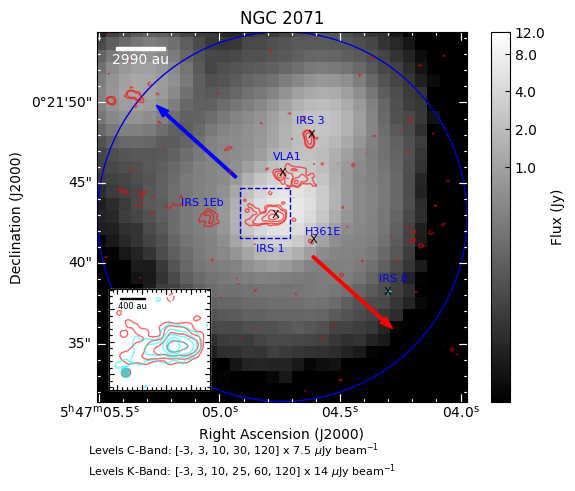

In [6]:
# To settle the direction of the ticks (direction=in) in the inset region
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'

# Paths for the sources data (table_coord) and dictionary with the contour levels
table_coord = f'Tables_Radio_{SOMA_subsample}/SOMA_coordinates.txt'
t_coord = np.genfromtxt(table_coord, names=True, dtype=None, encoding=None)

contour_levels_dic ='contour_levels_dic.p'
contour_levels_dic = pickle.load(open(contour_levels_dic, 'rb'))

#Paths for the FITS images
if SOMA_subsample == 'SOMA_2':
    IR_image_path = 'Images_FITS/Images_IR_SOFIA_37um_SOMAII_fits'
    VLA_image_path = 'Images_FITS/Images_Radio_SOMAII_fits'

elif SOMA_subsample == 'SOMA_3':
    IR_image_path = 'Images_FITS/Images_IR_SOFIA_37um_SOMAIII_fits'
    VLA_image_path = 'Images_FITS/Images_Radio_SOMAIII_fits'

#Color for the SOMA aperture
myblue ='#0000DD'
 
for i, source in enumerate(t_coord['source']): 
    if source == source_set: 
        #Ploting the IR image
        IR_fits_file = IR_image_path+'/'+source+'_SOFIA_37.1um_cal_ast.fits'
        
        hdu_IR = fits.open(IR_fits_file)[0]
        wcs_IR = WCS(hdu_IR.header)
            
        #fig, ax = plt.subplots()
        fig, ax = plt.subplots(subplot_kw={'projection': wcs_IR})
        lon = ax.coords[0]
        lat = ax.coords[1]
        
        #For better imaging, LogNorm and vmin=0.05
        #Liu et al. 2020 settings for the IR images
        #plt.imshow(hdu_IR.data, cmap='gnuplot', origin='lower',
        #           interpolation='bicubic', vmin=0, vmax=1) 
        #Rosero et al 2019 setting for the images

        vmax = (3 if source in ['IRAS_21391_MIR48', 'IRAS_16562_N'] else 12 if source in ['IRAS_22172_MIR1', 'IRAS_22172_MIR2', 'IRAS_22172_MIR3'] else contour_levels_dic[source]['Zoom_parameters']['vmax'])    
        vmin, vmax = 0.05, vmax
        norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=LogStretch())
        plt.imshow(hdu_IR.data, cmap='gray', origin='lower', norm=norm, interpolation='nearest')
        cbar = plt.colorbar()
        cbar.set_label('Flux (Jy)', family='sans-serif')

        if vmax == 3:    
            cbar.set_ticks([0.5, 1.0, 2.0, 3.0])
            cbar.set_ticklabels([0.5, 1.0, 2.0, 3.0])
        elif vmax == 6:
            cbar.set_ticks([1.0, 2.0, 4.0, 6.0])
            cbar.set_ticklabels([1.0, 2.0, 4.0, 6.0])
        elif vmax == 12:
            cbar.set_ticks([1.0, 2.0, 4.0, 8.0, 12.0])
            cbar.set_ticklabels([1.0, 2.0, 4.0, 8.0, 12.0])
        elif vmax == 16:
            cbar.set_ticks([1.0, 2.0, 4.0, 8.0, 12.0, 16.0])
            cbar.set_ticklabels([1.0, 2.0, 4.0, 8.0, 12.0, 16.0])
        
        #Ploting the VLA data and contour maps
        VLA_C_fits_file = VLA_image_path+'/'+source+'_C.image.fits'
        VLA_K_fits_file = VLA_image_path+'/'+source+'_K.image.fits'

        hdu_VLA_C = fits.open(VLA_C_fits_file)[0]
        data_VLA_C = hdu_VLA_C.data.squeeze()
        header_C = hdu_VLA_C.header
        wcs_VLA_C = WCS(header_C).celestial
        
        hdu_VLA_K = fits.open(VLA_K_fits_file)[0]
        data_VLA_K = hdu_VLA_K.data.squeeze()
        header_K = hdu_VLA_K.header
        wcs_VLA_K = WCS(header_K).celestial
        
        #Setting the values for the beam size
        B_min_C, B_maj_C, B_PA_C = hdu_VLA_C.header['BMIN'], hdu_VLA_C.header['BMAJ'], hdu_VLA_C.header['BPA']
        
        B_min_K, B_maj_K, B_PA_K = hdu_VLA_K.header['BMIN'], hdu_VLA_K.header['BMAJ'], hdu_VLA_K.header['BPA']
        
        #SOMA regions for the sources
        c = SkyCoord(ra=t_coord['RA'][i], dec=t_coord['Dec'][i], unit=(u.hourangle, u.deg))
        c_fk5 = c.transform_to('fk5')
        ra=c_fk5.ra.degree
        dec=c_fk5.dec.degree
        print(source)
        print(c_fk5)
        
        #Setting the contour levels for the C and K band data
        ax.contour(data_VLA_C, transform=ax.get_transform(wcs_VLA_C), 
                   levels=[element *t_coord['C_rms'][i]*1e-06 for element in contour_levels_dic[source]['Cont_Levels_SOMA']['C']], 
                   colors='red', linewidths=1, alpha=0.6, returnlevels=True)
        
        if source in ['IRAS_22172_MIR1', 'IRAS_22172_MIR2', 'IRAS_22172_MIR3','IRAS_21391_MIR48']:
            ax.contour(data_VLA_K, transform=ax.get_transform(wcs_VLA_K), 
                   levels=[element *t_coord['K_rms'][i]*1e-06 for element in contour_levels_dic[source]['Cont_Levels_SOMA']['K']], 
                   colors='cyan', linewidths=1, alpha=0.6, returnlevels=True)
        
        #Spherical Circles with astropy using RA, Dec and the SOMA aperture for each region.
        #All the values are in degrees (°)
        SOMA_region = SphericalCircle((ra * u.deg, dec * u.deg), 
                                      (t_coord['aperture_SOMA_deg'][i]/3600) * u.degree, 
                                      edgecolor=myblue, facecolor='none', transform=ax.get_transform('fk5'))
        ax.add_patch(SOMA_region)
      
        #Box for the zoom images with astropy using RA, Dec for each region.
        #All the values are in degrees (°)
        if 'Zoom_parameters' in contour_levels_dic[source].keys():
            # Value from the Contour Levels dictionary to set the figure
            source_factor = contour_levels_dic[source]['Zoom_parameters']['source_factor']

            #Set axis and ploting of the zoom image (inset region)
            ra_zoom = Angle(contour_levels_dic[source]['Zoom_parameters']['RA'], unit=u.hourangle).degree
            dec_zoom = Angle(contour_levels_dic[source]['Zoom_parameters']['Dec'], unit=u.deg).degree
            l_rectangule = contour_levels_dic[source]['Zoom_parameters']['l']
            
            zoom_region = Quadrangle((ra_zoom * u.deg, dec_zoom * u.deg), width = -source_factor*(l_rectangule/3600) * u.degree, 
                                    height = -(l_rectangule/3600) * u.degree, edgecolor=myblue, facecolor='none',
                                    linestyle='--', transform=ax.get_transform('fk5'))

            ax.add_patch(zoom_region)
        
        #Axis limits for the images
        x, y = wcs_IR.all_world2pix(ra, dec, 0)
        ax.set_xlim(x-t_coord['aperture_SOMA_pix'][i], x+t_coord['aperture_SOMA_pix'][i])
        ax.set_ylim(y-t_coord['aperture_SOMA_pix'][i], y+t_coord['aperture_SOMA_pix'][i])
        
        #Set the levels and rms for the contour maps
        if 'Zoom_parameters' in contour_levels_dic[source].keys():
            C_levels = [str(x) for x in contour_levels_dic[source]['Cont_Levels_Zoom']['C']] 
            C_rms = str(contour_levels_dic[source]['C_rms'])
            K_levels = [str(x) for x in contour_levels_dic[source]['Cont_Levels_Zoom']['K']] 
            K_rms = str(contour_levels_dic[source]['K_rms'])
    
            anot_C = 'Levels C-Band: [' + ', '.join(C_levels) + '] x ' + C_rms + r' $\mu$' + 'Jy beam' + r'$^{-1}$'
            anot_K = 'Levels K-Band: [' + ', '.join(K_levels) + '] x ' + K_rms + r' $\mu$' + 'Jy beam' + r'$^{-1}$'
        
            ax.annotate(anot_C + '\n' + anot_K, 
                    xy=(x-t_coord['aperture_SOMA_pix'][i]*1.05, y-t_coord['aperture_SOMA_pix'][i]*1.4), 
                    annotation_clip=False, fontsize=8, family='sans-serif')
        else:
            C_levels = [str(x) for x in contour_levels_dic[source]['Cont_Levels_SOMA']['C']] 
            C_rms = str(contour_levels_dic[source]['C_rms'])
            
            anot_C = 'Levels C-Band: [' + ', '.join(C_levels) + '] x ' + C_rms + r' $\mu$' + 'Jy beam' + r'$^{-1}$'
            
            ax.annotate(anot_C,
                    xy=(x-t_coord['aperture_SOMA_pix'][i]*1.05, y-t_coord['aperture_SOMA_pix'][i]*1.3), 
                    annotation_clip=False, fontsize=8, family='sans-serif')
            
        #Set the scale bar for the main image
        scale_arc = 2*t_coord['aperture_SOMA_deg'][i]/3.    # also I could choose it based on the radius like r/5
        scale = scale_arc/3600.     #  to deg
        label = (scale_arc*t_coord['Dist_SOMA'][i]*1000)    # AU
        print('Scale bar distance: ', label)
        fontprops = fm.FontProperties(size='10', family='sans-serif')
        scalebar = AnchoredSizeBar(ax.transData, 4, str(int(round(label,-1)))+' au', 'upper left', pad=1, 
                                   color='white', frameon=False, size_vertical=0.2, fontproperties=fontprops)
        ax.add_artist(scalebar)
        
        #Labels for the marks of the detections, see Contour_levels.py for details
        plot_label_mark(source_name=source, wcs_IR=wcs_IR, ax=ax)
        
        # showing the outflow direction
        if 'Outflow_parameters' in contour_levels_dic[source].keys():
            if source == 'IRAS_22172_MIR2':
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xb'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yb'],
                          contour_levels_dic[source]['Outflow_parameters']['x'],
                          contour_levels_dic[source]['Outflow_parameters']['y'], width=0.1, head_width=0.5, color='blue')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xr'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yr'],
                          -contour_levels_dic[source]['Outflow_parameters']['x'],
                          -contour_levels_dic[source]['Outflow_parameters']['y'], width=0.1, head_width=0.5, color='red') 
            elif source == 'IRAS_22198':
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xb'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yb'],
                          contour_levels_dic[source]['Outflow_parameters']['x'],
                          contour_levels_dic[source]['Outflow_parameters']['y'], width=0.2, head_width=0.7, color='red')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xr'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yr'],
                          -contour_levels_dic[source]['Outflow_parameters']['x'],
                          -contour_levels_dic[source]['Outflow_parameters']['y'], width=0.2, head_width=0.7, color='blue') 
            elif source == 'G45.12+0.13':
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xb'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yb'],
                          contour_levels_dic[source]['Outflow_parameters']['x'],
                          contour_levels_dic[source]['Outflow_parameters']['y'], width=0.8, head_width=2.5, color='blue')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xr'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yr'],
                          -contour_levels_dic[source]['Outflow_parameters']['x'],
                          -contour_levels_dic[source]['Outflow_parameters']['y'], width=0.8, head_width=2.5, color='red') 
            else:
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xb'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yb'],
                          contour_levels_dic[source]['Outflow_parameters']['x'],
                          contour_levels_dic[source]['Outflow_parameters']['y'], width=0.2, head_width=0.7, color='blue')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters']['xr'],
                          y+contour_levels_dic[source]['Outflow_parameters']['yr'],
                          -contour_levels_dic[source]['Outflow_parameters']['x'],
                          -contour_levels_dic[source]['Outflow_parameters']['y'], width=0.2, head_width=0.7, color='red') 
                
        if 'Outflow_parameters_2' in contour_levels_dic[source].keys():
            if source == 'G45.12+0.13':
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_2']['xb'],
                              y+contour_levels_dic[source]['Outflow_parameters_2']['yb'],
                              contour_levels_dic[source]['Outflow_parameters_2']['x'],
                              contour_levels_dic[source]['Outflow_parameters_2']['y'], width=0.8, head_width=2.5, color='red')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_2']['xr'],
                              y+contour_levels_dic[source]['Outflow_parameters_2']['yr'],
                              -contour_levels_dic[source]['Outflow_parameters_2']['x'],
                              -contour_levels_dic[source]['Outflow_parameters_2']['y'], width=0.8, head_width=2.5, color='blue')
            else:
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_2']['xb'],
                              y+contour_levels_dic[source]['Outflow_parameters_2']['yb'],
                              contour_levels_dic[source]['Outflow_parameters_2']['x'],
                              contour_levels_dic[source]['Outflow_parameters_2']['y'], width=0.2, head_width=0.7, color='red')  
                plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_2']['xr'],
                              y+contour_levels_dic[source]['Outflow_parameters_2']['yr'],
                              -contour_levels_dic[source]['Outflow_parameters_2']['x'],
                              -contour_levels_dic[source]['Outflow_parameters_2']['y'], width=0.2, head_width=0.7, color='blue')

        if 'Outflow_parameters_3' in contour_levels_dic[source].keys():
            plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_3']['xb'],
                          y+contour_levels_dic[source]['Outflow_parameters_3']['yb'],
                          contour_levels_dic[source]['Outflow_parameters_3']['x'],
                          contour_levels_dic[source]['Outflow_parameters_3']['y'], width=0.2, head_width=0.7, color='red')  

        if 'Outflow_parameters_4' in contour_levels_dic[source].keys():
            plt.arrow(x+contour_levels_dic[source]['Outflow_parameters_4']['xr'],
                          y+contour_levels_dic[source]['Outflow_parameters_4']['yr'],
                          contour_levels_dic[source]['Outflow_parameters_4']['x'],
                          contour_levels_dic[source]['Outflow_parameters_4']['y'], width=0.2, head_width=0.7, color='blue') 
                
        #Zoom image (inset region), made using Viviana's script with APLPY
        if 'Zoom_parameters' in contour_levels_dic[source].keys():
            if source in['L1206_A', 'IRAS_21391_BIMA3']:
                position=[0.54,0.135,0.21,0.21]
            elif source in ['IRAS_22198', 'IRAS_16562']:
                position=[0.142,0.13,0.21,0.21]
            elif source in ['G35.58-0.03']:
                position=[0.16,0.135,0.23,0.23]
            else:
                position=[0.16,0.135,0.21,0.21] 
            
            ax_sub = fig.add_subplot(projection=wcs_VLA_C, position=position)
            ax_sub.set_aspect('equal')
            
            ax_sub.contour(data_VLA_C, transform=ax_sub.get_transform(wcs_VLA_C), 
                       levels=[element *t_coord['C_rms'][i]*1e-06 for element in contour_levels_dic[source]['Cont_Levels_Zoom']['C']], 
                       colors='red', linewidths=1, alpha=0.6, returnlevels=True)
            
            ax_sub.contour(data_VLA_K, transform=ax_sub.get_transform(wcs_VLA_K), 
                       levels=[element *t_coord['K_rms'][i]*1e-06 for element in contour_levels_dic[source]['Cont_Levels_Zoom']['K']], 
                       colors='cyan', linewidths=1, alpha=0.6, returnlevels=True)
            
            scale_arc_ins = source_factor*l_rectangule/3.    # also I could choose it based on the radius like r/5
            scale = scale_arc/3600.     #  to deg
            label = (scale_arc_ins*t_coord['Dist_SOMA'][i]*1000)    # AU
            fontprops = fm.FontProperties(size='6', family='sans-serif')
            scalebar = AnchoredSizeBar(ax.transData, 2, str(int(round(label,-1)))+' au', 'upper left', pad=1, 
                                       color='black', frameon=False, size_vertical=0.1, fontproperties=fontprops)
            ax_sub.add_artist(scalebar)
            plot_label_mark_inset(source_name=source, wcs_IR=wcs_VLA_C, ax=ax_sub)
            
            #Set the beam in the inset region
            if source in ['IRAS_21391_BIMA2', 'IRAS_22198', 'Cepheus_E', 'G49.27-0.34']:
                add_beam(ax_sub, major= B_maj_C, minor= B_min_C, angle=B_PA_C, fill=True, color='red', alpha=0.6, corner='bottom right')
                add_beam(ax_sub, major= B_maj_K, minor= B_min_K, angle=B_PA_K, fill=True, color='cyan', alpha=0.6, corner='bottom right')
            elif source != 'IRAS_16562': 
                add_beam(ax_sub, major= B_maj_C, minor= B_min_C, angle=B_PA_C, fill=True, color='red', alpha=0.6)
                add_beam(ax_sub, major= B_maj_K, minor= B_min_K, angle=B_PA_K, fill=True, color='cyan', alpha=0.6)
            
            #Set axis and ploting of the zoom image (inset region)
            ra_zoom = contour_levels_dic[source]['Zoom_parameters']['RA']
            dec_zoom = contour_levels_dic[source]['Zoom_parameters']['Dec']
            l_rectangule = contour_levels_dic[source]['Zoom_parameters']['l']/3600 * u.deg

            # Convert the RA to a SkyCoord object
            coord = SkyCoord(ra=ra_zoom, dec=dec_zoom, unit=(u.hourangle, u.deg), frame='icrs')
            new_ra = (coord.ra - l_rectangule*source_factor).to_string(unit=u.hourangle, sep=':', precision=3)
            new_dec = (coord.dec - l_rectangule).to_string(unit=u.deg, sep=':', precision=3, alwayssign=True)

            x_min, y_max = skycoord_to_pixel(SkyCoord(ra=contour_levels_dic[source]['Zoom_parameters']['RA'], 
                                            dec=contour_levels_dic[source]['Zoom_parameters']['Dec'], 
                                            unit=(u.hourangle, u.deg)), wcs_VLA_C)
            
            x_max, y_min = skycoord_to_pixel(SkyCoord(ra=new_ra, dec=new_dec, unit=(u.hourangle, u.deg)), wcs_VLA_C)

            ax_sub.set_xlim(x_min, x_max)
            ax_sub.set_ylim(y_min, y_max)
            ax_sub.tick_params(axis='x', which='both', labelbottom=False)
            ax_sub.tick_params(axis='y', which='both', labelleft=False)
            ax_sub.coords[0].display_minor_ticks(True)
            ax_sub.coords[1].display_minor_ticks(True)

        else: 
            #Set the beam in the plot for sources without detection (no inset region)
            add_beam(ax, major= B_maj_C, minor= B_min_C, angle=B_PA_C, fill=True, color='red', alpha=0.6)
            #add_beam(ax, major= B_maj_K, minor= B_min_K, angle=B_PA_K, fill=True, color='cyan', alpha=0.6)

        if source == 'IRAS_16562':
            #Set the beam in the plot for sources without detection (no inset region)
            add_beam(ax, major= B_maj_C, minor= B_min_C, angle=B_PA_C, fill=True, color='red', alpha=0.6, corner='bottom right')
            add_beam(ax, major= B_maj_K, minor= B_min_K, angle=B_PA_K, fill=True, color='cyan', alpha=0.6, corner='bottom right')
        
        #Set title, axis and ploting
        if source == 'IRAS_22198':    
            ax.set_title(source.replace('_',' ')+'+6336')
        elif source == 'IRAS_21391_BIMA2':
            ax.set_title('IRAS 21391+5802 BIMA2')
        elif source == 'IRAS_21391_BIMA3':
            ax.set_title('IRAS 21391+5802 BIMA3')
        elif source == 'IRAS_21391_MIR48':
            ax.set_title('IRAS 21391+5802 MIR48')
        elif source == 'IRAS_22172_MIR1':
            ax.set_title('IRAS 22172+5549 MIR1')
        elif source == 'IRAS_22172_MIR2': 
            ax.set_title('IRAS 22172+5549 MIR2')
        elif source == 'IRAS_22172_MIR3':   
            ax.set_title('IRAS 22172+5549 MIR3')   
        elif source == 'IRAS_16562':   
            ax.set_title('IRAS 16562−3959') 
        elif source == 'IRAS_16562_N':   
            ax.set_title('IRAS 16562−3959 N')
        elif source == 'G305.20+0.21A':   
            ax.set_title('G305.21+0.21 (G305A)')
        elif source == 'G305.20+0.21':   
            ax.set_title('G305.20+0.21 (G305B)')
        else:
            ax.set_title(source.replace('_',' '))   
            
        lon.set_axislabel(r'Right Ascension (J2000)', family='sans-serif')
        lon.set_ticklabel(exclude_overlapping=True)
        lon.display_minor_ticks(True)
        lon.tick_params(direction='in', length=6, color='white')
        lat.set_axislabel(r'Declination (J2000)', family='sans-serif')
        lat.set_ticklabel(exclude_overlapping=True)
        lat.display_minor_ticks(True)
        lat.tick_params(direction='in', length=6, color='white')
        #path = 'Paper_and_presentation/Contour Images/'
        #plt.savefig(path+source+'_VLA_contours.png', bbox_inches='tight', pad_inches=0.0)
        #plt.savefig(path+source+'_VLA_contours.pdf', bbox_inches='tight', pad_inches=0.0)
        plt.show()
        plt.close()
    
    else:
        continue